## **What subject does the dataset cover?**
According to the CDC, heart disease is a leading cause of death for people of most races in the U.S. (African Americans, American Indians and Alaska Natives, and whites). About half of all Americans (47%) have at least 1 of 3 major risk factors for heart disease: high blood pressure, high cholesterol, and smoking. Other key indicators include diabetes status, obesity (high BMI), not getting enough physical activity, or drinking too much alcohol. Identifying and preventing the factors that have the greatest impact on heart disease is very important in healthcare. In turn, developments in computing allow the application of machine learning methods to detect "patterns" in the data that can predict a patient's condition.


#### **Where did the data set come from and what treatments has it undergone?**
The dataset originally comes from the CDC and is a major part of the Behavioral Risk Factor Surveillance System (BRFSS), which conducts annual telephone surveys to collect data on the health status of U.S. residents. As described by the CDC: "Established in 1984 with 15 states, BRFSS now collects data in all 50 states, the District of Columbia, and three U.S. territories. BRFSS completes more than 400,000 adult interviews each year, making it the largest continuously conducted health survey system in the world. The most recent dataset includes data from 2023. In this dataset, I noticed many factors (questions) that directly or indirectly influence heart disease, so I decided to select the most relevant variables from it. I also decided to share with you two versions of the most recent dataset: with NaNs and without it.

#### **Features of Data**

**HeartDisease**: Target variable. Indicates whether the respondent has ever been diagnosed with coronary heart disease (CHD) or had a myocardial infarction (heart attack).

**BMI**: Body Mass Index. A numerical measure of body fat calculated as weight (kg) divided by height (m) squared. Higher values indicate overweight/obesity, which is a known cardiovascular risk factor.

**Smoking**: Whether the respondent has smoked at least 100 cigarettes (approximately 5 packs) in their entire lifetime.

**AlcoholDrinking**: Whether the respondent is classified as a heavy drinker (adult men having more than 14 drinks per week, or adult women having more than 7 drinks per week).

**Stroke**: Whether the respondent has ever been told by a doctor that they had a stroke. Stroke and heart disease share many common risk factors.

**PhysicalHealth**: Self-reported number of days during the past 30 days when the respondent's physical health was not good (includes physical illness and injury). 0 means no bad days.

**MentalHealth**: Self-reported number of days during the past 30 days when the respondent's mental health was not good (includes stress, depression, and emotional problems). 0 means no bad days.

**DiffWalking**: Whether the respondent has serious difficulty walking or climbing stairs. Serves as a proxy for physical disability and reduced mobility.

**Sex**: Biological sex of the respondent. Males are generally at higher risk for heart disease.

**AgeCategory**: Age group of the respondent, bucketed into 5-year intervals (e.g., 18-24, 25-29, … 80 or older). Older age is one of the strongest risk factors for heart disease.

**Race**: Self-reported race/ethnicity of the respondent. Categories include: White, Black, Hispanic, Asian, American Indian/Alaskan Native, and Other.

**Diabetic**: Diabetes status of the respondent. Possible values: Yes, No, No, borderline diabetes, and Yes (during pregnancy). Diabetes significantly increases cardiovascular risk.

**PhysicalActivity**: Whether the respondent reported doing physical activity or exercise during the past 30 days (other than their regular job).

**GenHealth**: Self-rated general health status on a 5-level scale: Poor, Fair, Good, Very good, Excellent. Strong predictor of overall health outcomes.

**SleepTime**: Average number of hours of sleep the respondent gets in a 24-hour period. Both too little (<7h) and too much (>9h) sleep are associated with increased cardiovascular risk.

**Asthma**: Whether the respondent has ever been told by a doctor that they have asthma. Chronic respiratory conditions can be comorbid with heart disease.

**KidneyDisease**: Whether the respondent has ever been told they have kidney disease (excluding kidney stones, bladder infections, or incontinence). Kidney disease is strongly linked to cardiovascular events.

**SkinCancer**: Whether the respondent has ever been told they have skin cancer. Included as a general comorbidity indicator.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

#### **Load Data**

In [2]:
df = pd.read_csv('../data/heart_data.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319795 entries, 0 to 319794
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   HeartDisease      319795 non-null  object 
 1   BMI               319795 non-null  float64
 2   Smoking           319795 non-null  object 
 3   AlcoholDrinking   319795 non-null  object 
 4   Stroke            319795 non-null  object 
 5   PhysicalHealth    319795 non-null  float64
 6   MentalHealth      319795 non-null  float64
 7   DiffWalking       319795 non-null  object 
 8   Sex               319795 non-null  object 
 9   AgeCategory       319795 non-null  object 
 10  Race              319795 non-null  object 
 11  Diabetic          319795 non-null  object 
 12  PhysicalActivity  319795 non-null  object 
 13  GenHealth         319795 non-null  object 
 14  SleepTime         319795 non-null  float64
 15  Asthma            319795 non-null  object 
 16  KidneyDisease     31

In [3]:
df.duplicated().sum()

np.int64(18078)

In [4]:
df.isnull().sum()

HeartDisease        0
BMI                 0
Smoking             0
AlcoholDrinking     0
Stroke              0
PhysicalHealth      0
MentalHealth        0
DiffWalking         0
Sex                 0
AgeCategory         0
Race                0
Diabetic            0
PhysicalActivity    0
GenHealth           0
SleepTime           0
Asthma              0
KidneyDisease       0
SkinCancer          0
dtype: int64

In [5]:
df.drop_duplicates(inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 301717 entries, 0 to 319794
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   HeartDisease      301717 non-null  object 
 1   BMI               301717 non-null  float64
 2   Smoking           301717 non-null  object 
 3   AlcoholDrinking   301717 non-null  object 
 4   Stroke            301717 non-null  object 
 5   PhysicalHealth    301717 non-null  float64
 6   MentalHealth      301717 non-null  float64
 7   DiffWalking       301717 non-null  object 
 8   Sex               301717 non-null  object 
 9   AgeCategory       301717 non-null  object 
 10  Race              301717 non-null  object 
 11  Diabetic          301717 non-null  object 
 12  PhysicalActivity  301717 non-null  object 
 13  GenHealth         301717 non-null  object 
 14  SleepTime         301717 non-null  float64
 15  Asthma            301717 non-null  object 
 16  KidneyDisease     301717 

In [6]:
df.describe()

,BMI,PhysicalHealth,MentalHealth,SleepTime
count,301717.000000,301717.000000,301717.000000,301717.000000
mean,28.441970,3.572298,4.121475,7.084559
std,6.468134,8.140656,8.128288,1.467122
min,12.020000,0.000000,0.000000,1.000000
25%,24.030000,0.000000,0.000000,6.000000
50%,27.410000,0.000000,0.000000,7.000000
75%,31.650000,2.000000,4.000000,8.000000
max,94.850000,30.000000,30.000000,24.000000


## **Preprocessing**

In [7]:
df = df[(df['BMI'] >= 12) & (df['BMI'] <= 60)]

In [8]:
df.head()

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,16.60,Yes,No,No,3.0,30.0,No,Female,55-59,White,Yes,Yes,Very good,5.0,Yes,No,Yes
1,No,20.34,No,No,Yes,0.0,0.0,No,Female,80 or older,White,No,Yes,Very good,7.0,No,No,No
2,No,26.58,Yes,No,No,20.0,30.0,No,Male,65-69,White,Yes,Yes,Fair,8.0,Yes,No,No
3,No,24.21,No,No,No,0.0,0.0,No,Female,75-79,White,No,No,Good,6.0,No,No,Yes
4,No,23.71,No,No,No,28.0,0.0,Yes,Female,40-44,White,No,Yes,Very good,8.0,No,No,No


In [9]:
df['HeartDisease'].value_counts()

HeartDisease
No     274021
Yes     27204
Name: count, dtype: int64

In [10]:
df['HeartDisease'] = (df['HeartDisease'] == 'Yes').astype(int)
df['HeartDisease'].value_counts()

HeartDisease
0    274021
1     27204
Name: count, dtype: int64

In [11]:
df.columns

Index(['HeartDisease', 'BMI', 'Smoking', 'AlcoholDrinking', 'Stroke',
       'PhysicalHealth', 'MentalHealth', 'DiffWalking', 'Sex', 'AgeCategory',
       'Race', 'Diabetic', 'PhysicalActivity', 'GenHealth', 'SleepTime',
       'Asthma', 'KidneyDisease', 'SkinCancer'],
      dtype='object')

In [12]:
df.head()

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,0,16.60,Yes,No,No,3.0,30.0,No,Female,55-59,White,Yes,Yes,Very good,5.0,Yes,No,Yes
1,0,20.34,No,No,Yes,0.0,0.0,No,Female,80 or older,White,No,Yes,Very good,7.0,No,No,No
2,0,26.58,Yes,No,No,20.0,30.0,No,Male,65-69,White,Yes,Yes,Fair,8.0,Yes,No,No
3,0,24.21,No,No,No,0.0,0.0,No,Female,75-79,White,No,No,Good,6.0,No,No,Yes
4,0,23.71,No,No,No,28.0,0.0,Yes,Female,40-44,White,No,Yes,Very good,8.0,No,No,No


In [13]:
cols = ['Smoking', 'AlcoholDrinking', 'Stroke','DiffWalking','Diabetic', 'PhysicalActivity','Asthma', 'KidneyDisease', 'SkinCancer']
for col in cols:
    df[col] = (df[col] == 'Yes').astype(int)
    print(f"{col} value counts:\n{df[col].value_counts()}\n")

Smoking value counts:
Smoking
0    174021
1    127204
Name: count, dtype: int64

AlcoholDrinking value counts:
AlcoholDrinking
0    279675
1     21550
Name: count, dtype: int64

Stroke value counts:
Stroke
0    289188
1     12037
Name: count, dtype: int64

DiffWalking value counts:
DiffWalking
0    257134
1     44091
Name: count, dtype: int64

Diabetic value counts:
Diabetic
0    260792
1     40433
Name: count, dtype: int64

PhysicalActivity value counts:
PhysicalActivity
1    230163
0     71062
Name: count, dtype: int64

Asthma value counts:
Asthma
0    258727
1     42498
Name: count, dtype: int64

KidneyDisease value counts:
KidneyDisease
0    289492
1     11733
Name: count, dtype: int64

SkinCancer value counts:
SkinCancer
0    271950
1     29275
Name: count, dtype: int64



In [14]:
df['Sex'] = (df['Sex'] == 'Male').astype(int)
df['Sex'].value_counts()

Sex
0    159353
1    141872
Name: count, dtype: int64

In [15]:
df = df.drop(columns = ['Race'], axis = 1)
df.head()

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,0,16.60,1,0,0,3.0,30.0,0,0,55-59,1,1,Very good,5.0,1,0,1
1,0,20.34,0,0,1,0.0,0.0,0,0,80 or older,0,1,Very good,7.0,0,0,0
2,0,26.58,1,0,0,20.0,30.0,0,1,65-69,1,1,Fair,8.0,1,0,0
3,0,24.21,0,0,0,0.0,0.0,0,0,75-79,0,0,Good,6.0,0,0,1
4,0,23.71,0,0,0,28.0,0.0,1,0,40-44,0,1,Very good,8.0,0,0,0


In [16]:
df['AgeCategory'].unique()

array(['55-59', '80 or older', '65-69', '75-79', '40-44', '70-74',
       '60-64', '50-54', '45-49', '18-24', '35-39', '30-34', '25-29'],
      dtype=object)

In [17]:
df['AgeCategory'] = df['AgeCategory'].map({
    '18-24': 0,'25-29': 1,'30-34': 2,'35-39': 3,'40-44': 4,'45-49': 5,'50-54': 6,
    '55-59': 7,'60-64': 8,'65-69': 9,'70-74': 10,'75-79': 11,'80 or older': 12})

df['AgeCategory'].value_counts()

AgeCategory
9     31642
8     31177
10    29259
7     27547
6     23673
12    23344
11    20710
5     20456
0     19973
4     19777
3     19473
2     17904
1     16290
Name: count, dtype: int64

In [18]:
df['GenHealth'].unique()

array(['Very good', 'Fair', 'Good', 'Poor', 'Excellent'], dtype=object)

In [19]:
df['GenHealth'] = df['GenHealth'].map({
    'Poor': 0,'Fair': 1,'Good': 2,'Very good': 3,'Excellent': 4})

df['GenHealth'].value_counts()

GenHealth
3    104740
2     91090
4     59701
1     34503
0     11191
Name: count, dtype: int64

In [20]:
df.head()

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,0,16.60,1,0,0,3.0,30.0,0,0,7,1,1,3,5.0,1,0,1
1,0,20.34,0,0,1,0.0,0.0,0,0,12,0,1,3,7.0,0,0,0
2,0,26.58,1,0,0,20.0,30.0,0,1,9,1,1,1,8.0,1,0,0
3,0,24.21,0,0,0,0.0,0.0,0,0,11,0,0,2,6.0,0,0,1
4,0,23.71,0,0,0,28.0,0.0,1,0,4,0,1,3,8.0,0,0,0


In [21]:
df.duplicated().sum()

np.int64(7119)

In [22]:
df = df.drop_duplicates()

## **Data Visualization**

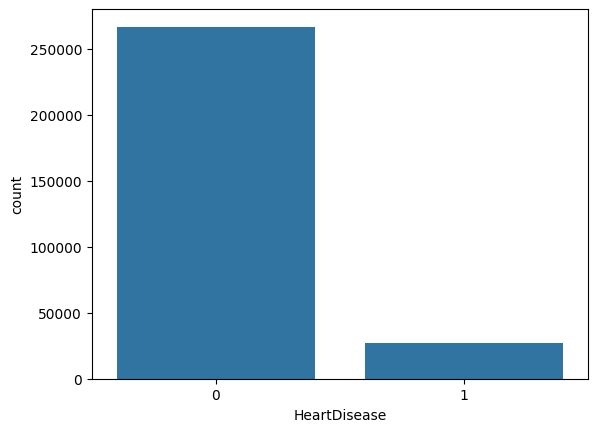

In [23]:
sns.countplot(x = 'HeartDisease', data = df)
plt.show()

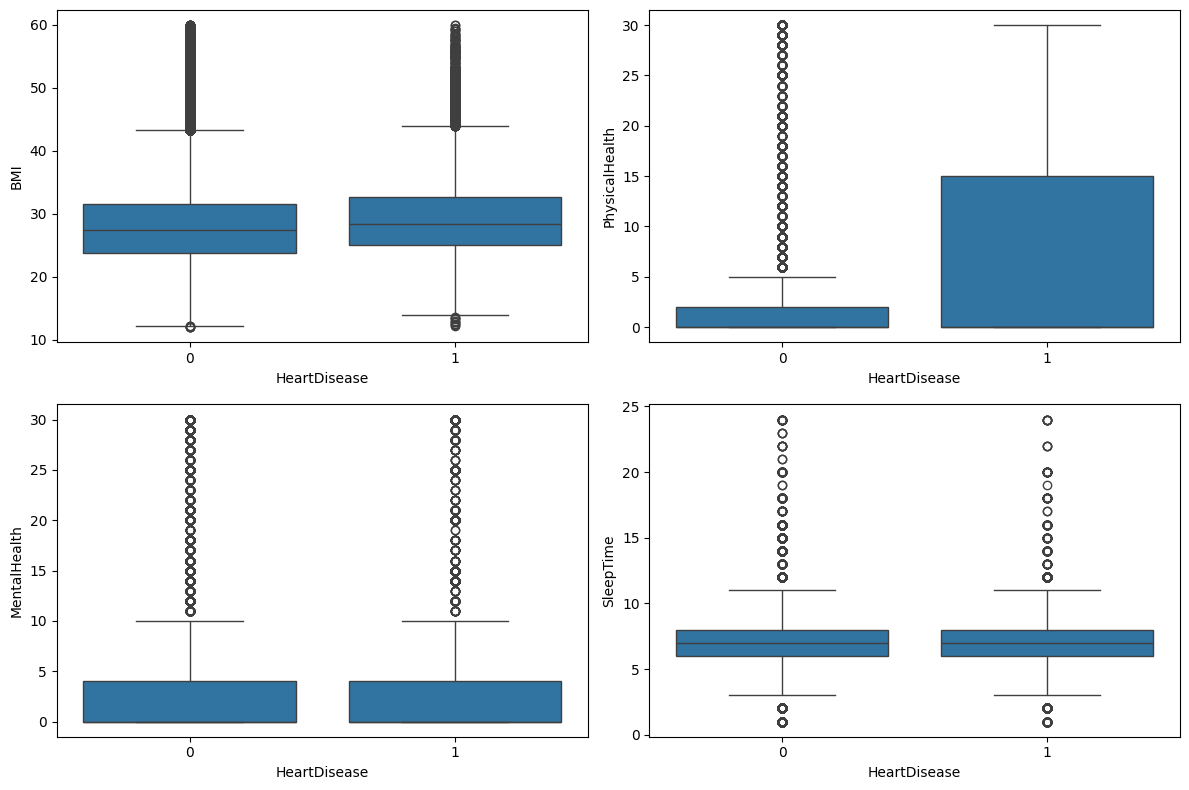

In [24]:
nums_cols = ['BMI', 'PhysicalHealth', 'MentalHealth', 'SleepTime']

fig, axes = plt.subplots(2,2,figsize = (12,8))
axes = axes.flatten()

for i,col in enumerate(nums_cols):
    sns.boxplot(x='HeartDisease', y=col, data=df, ax=axes[i])
plt.tight_layout()
plt.show()

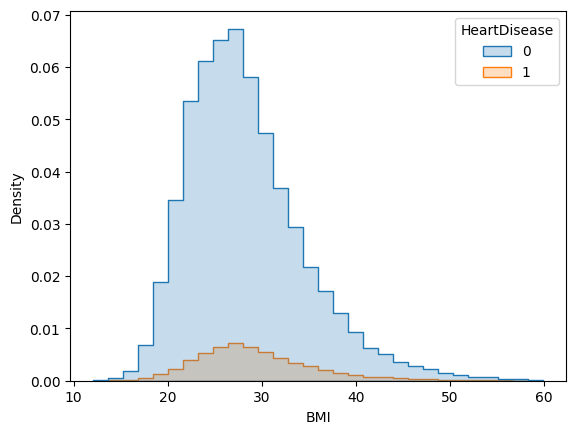

In [25]:
sns.histplot(data=df, x = 'BMI', hue = 'HeartDisease', bins=30, element='step', stat='density')
plt.show()

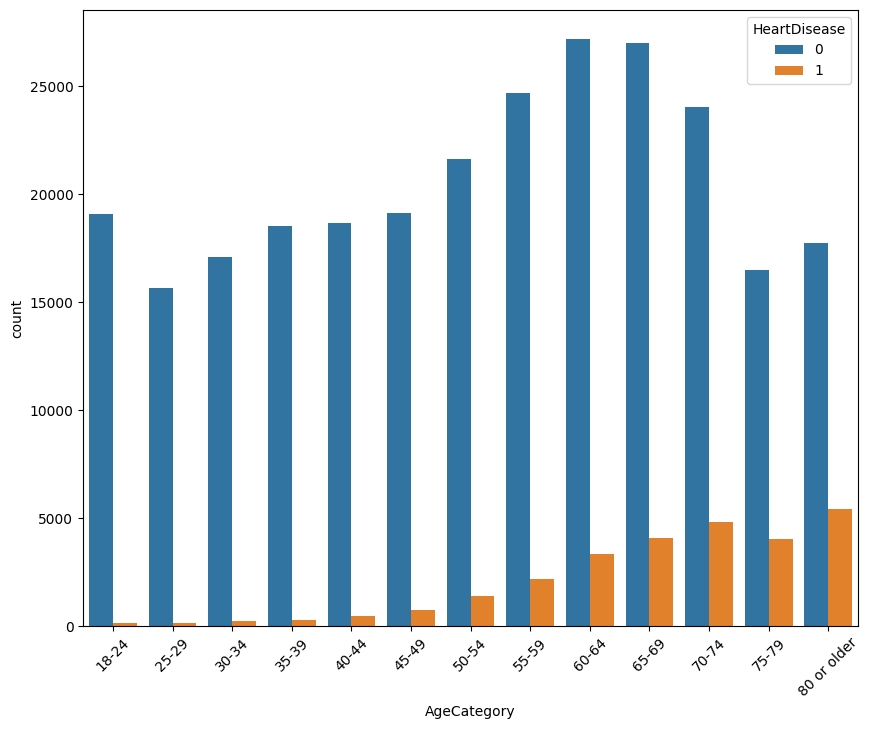

In [26]:
plt.figure(figsize = (10,8))
sns.countplot(data=df, x = 'AgeCategory', hue = 'HeartDisease')
plt.xticks(rotation = 45,ticks=[0,1,2,3,4,5,6,7,8,9,10,11,12],
labels=['18-24','25-29','30-34','35-39','40-44','45-49',
'50-54','55-59', '60-64','65-69','70-74', '75-79', '80 or older'])
plt.show()

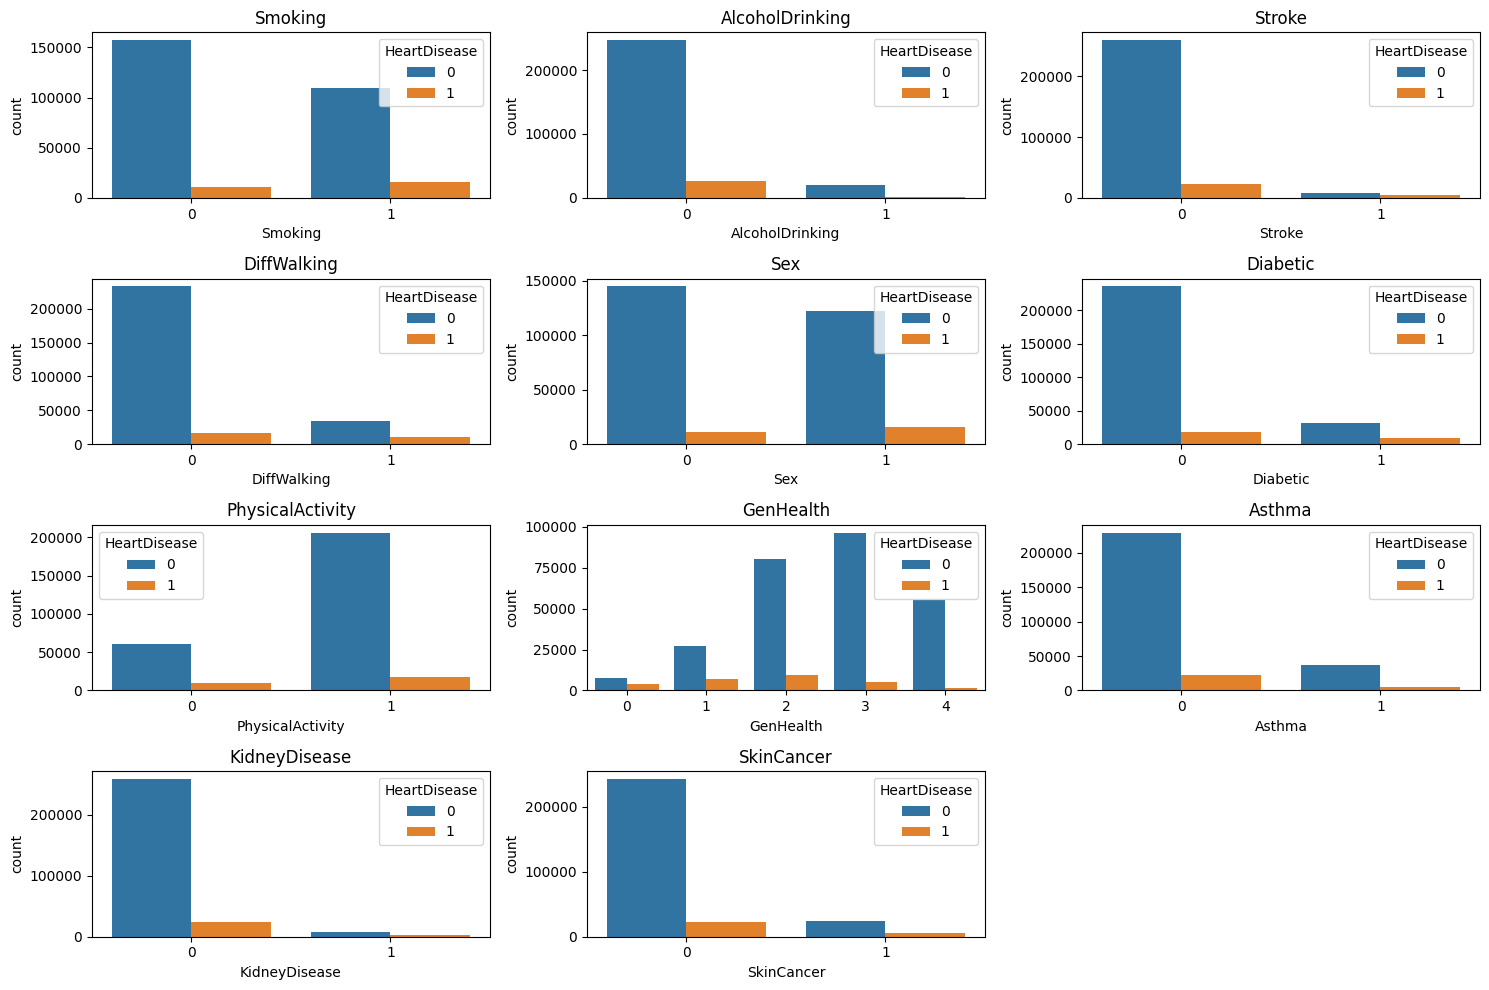

In [27]:
cat_cols = ['Smoking','AlcoholDrinking','Stroke','DiffWalking',
            'Sex','Diabetic','PhysicalActivity','GenHealth',
            'Asthma','KidneyDisease','SkinCancer']

n_cols = 3
n_rows = 4 

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(x=col, hue='HeartDisease', data=df, ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis='x')


for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

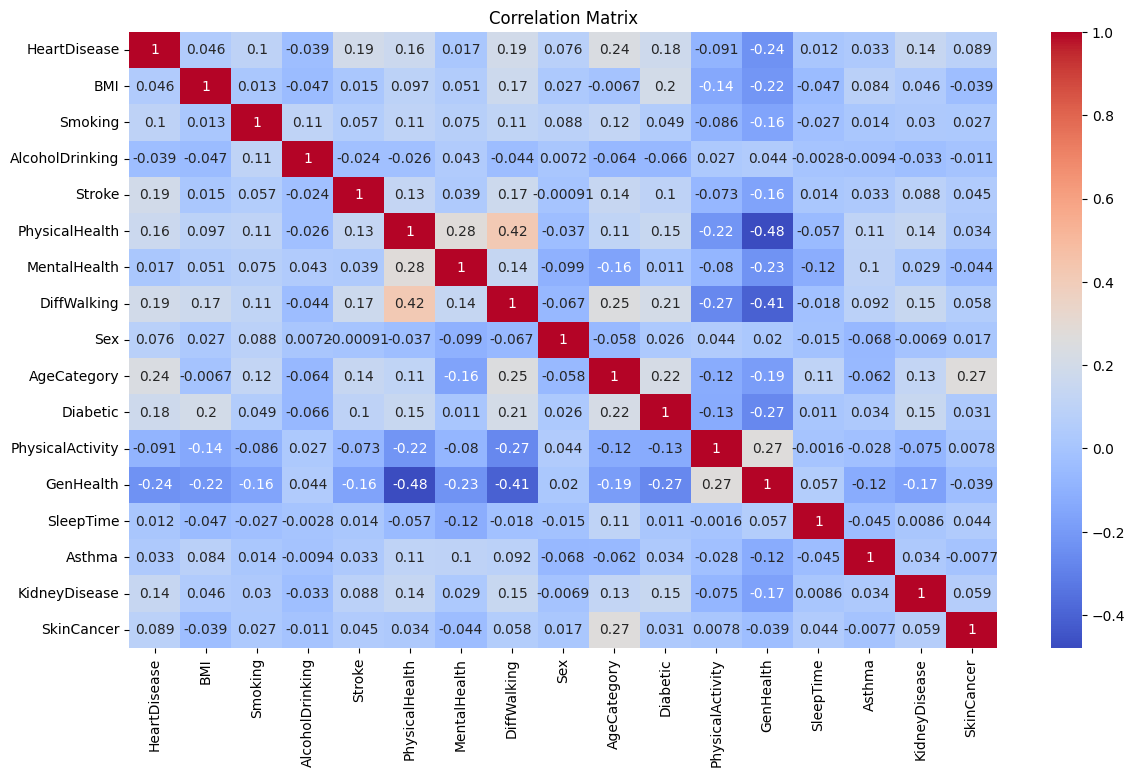

In [28]:
plt.figure(figsize=(14,8))
sns.heatmap(data = df.corr(), annot=True,cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

## **Train Models**

In [29]:
from sklearn.model_selection import train_test_split
X = df.drop(columns = ['HeartDisease'], axis = 1)
y = df['HeartDisease']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [30]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [31]:
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.99      0.95     53385
           1       0.53      0.11      0.18      5437

    accuracy                           0.91     58822
   macro avg       0.72      0.55      0.57     58822
weighted avg       0.88      0.91      0.88     58822



In [32]:
from sklearn.ensemble import RandomForestClassifier
model_rf = RandomForestClassifier(random_state=42, class_weight='balanced', n_estimators=300, max_depth=15)
model_rf.fit(X_train, y_train)
y_pred = model_rf.predict(X_test)

In [33]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.81      0.87     53385
           1       0.25      0.63      0.36      5437

    accuracy                           0.79     58822
   macro avg       0.60      0.72      0.61     58822
weighted avg       0.89      0.79      0.83     58822



In [34]:
importance = model_rf.feature_importances_

feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feat_imp.sort_values(by='Importance', ascending=False, inplace=True)
print(feat_imp[:12])

           Feature  Importance
8      AgeCategory    0.315268
11       GenHealth    0.147634
0              BMI    0.101175
6      DiffWalking    0.055724
4   PhysicalHealth    0.055523
9         Diabetic    0.052654
3           Stroke    0.049980
12       SleepTime    0.047928
7              Sex    0.044299
5     MentalHealth    0.041062
1          Smoking    0.023122
14   KidneyDisease    0.017774


##### **Solve The Imbalance**

In [35]:
from imblearn.under_sampling import RandomUnderSampler, NearMiss

rus = RandomUnderSampler(random_state=42)
X_balanced  ,y_balanced= rus.fit_resample(X, y)
y_balanced.value_counts()

HeartDisease
0    27184
1    27184
Name: count, dtype: int64

#### **Models Comparison**

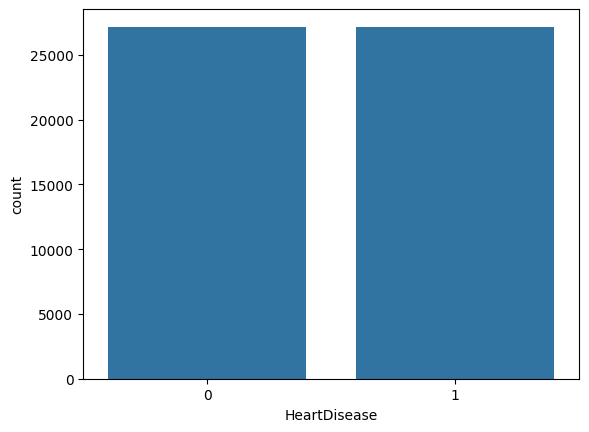

In [36]:
sns.countplot(x = 'HeartDisease', data = pd.DataFrame(y_balanced))
plt.show()

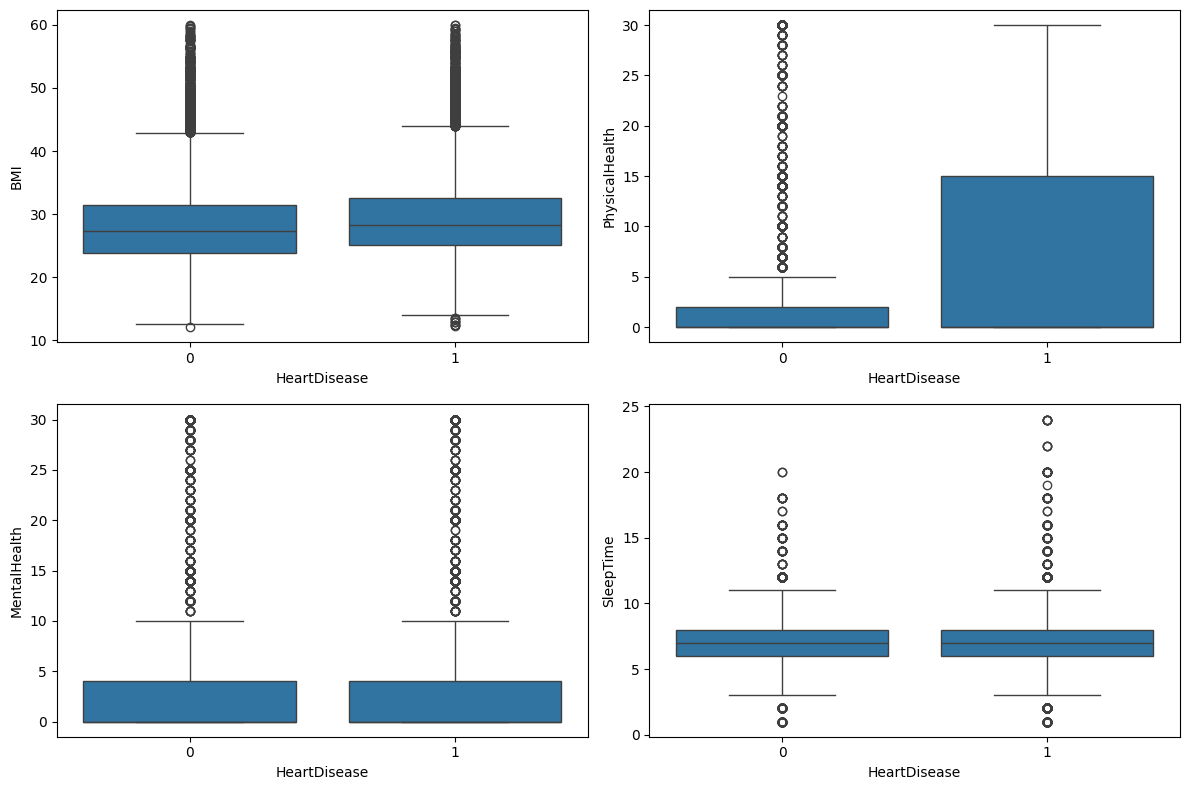

In [37]:
nums_cols = ['BMI', 'PhysicalHealth', 'MentalHealth', 'SleepTime']

fig, axes = plt.subplots(2,2,figsize = (12,8))
axes = axes.flatten()
data = X_balanced.copy()
data['HeartDisease'] = y_balanced
for i,col in enumerate(nums_cols):
    sns.boxplot(x='HeartDisease', y=col, data=data, ax=axes[i])
plt.tight_layout()
plt.show()

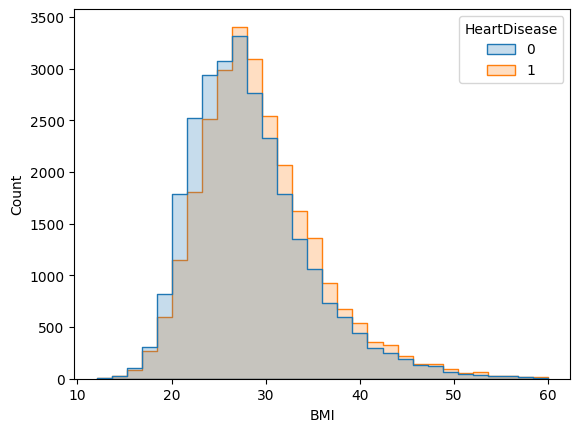

In [38]:
sns.histplot(data=data, x = 'BMI', hue = 'HeartDisease', bins=30, element='step')
plt.show()

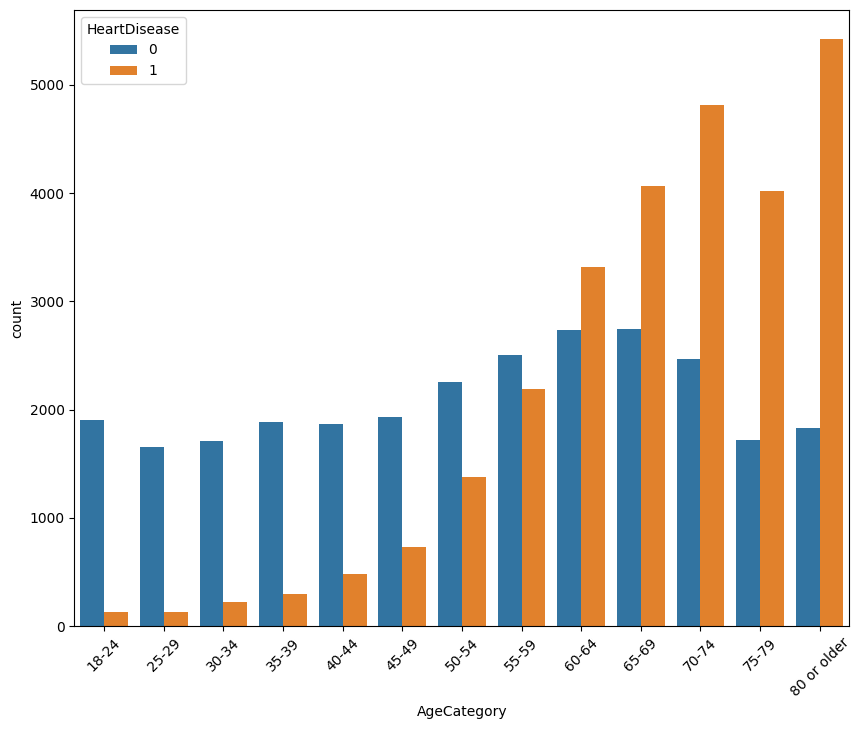

In [39]:
plt.figure(figsize = (10,8))
sns.countplot(data=data, x = 'AgeCategory', hue = 'HeartDisease')
plt.xticks(rotation = 45,ticks=[0,1,2,3,4,5,6,7,8,9,10,11,12],
labels=['18-24','25-29','30-34','35-39','40-44','45-49',
'50-54','55-59', '60-64','65-69','70-74', '75-79', '80 or older'])
plt.show()

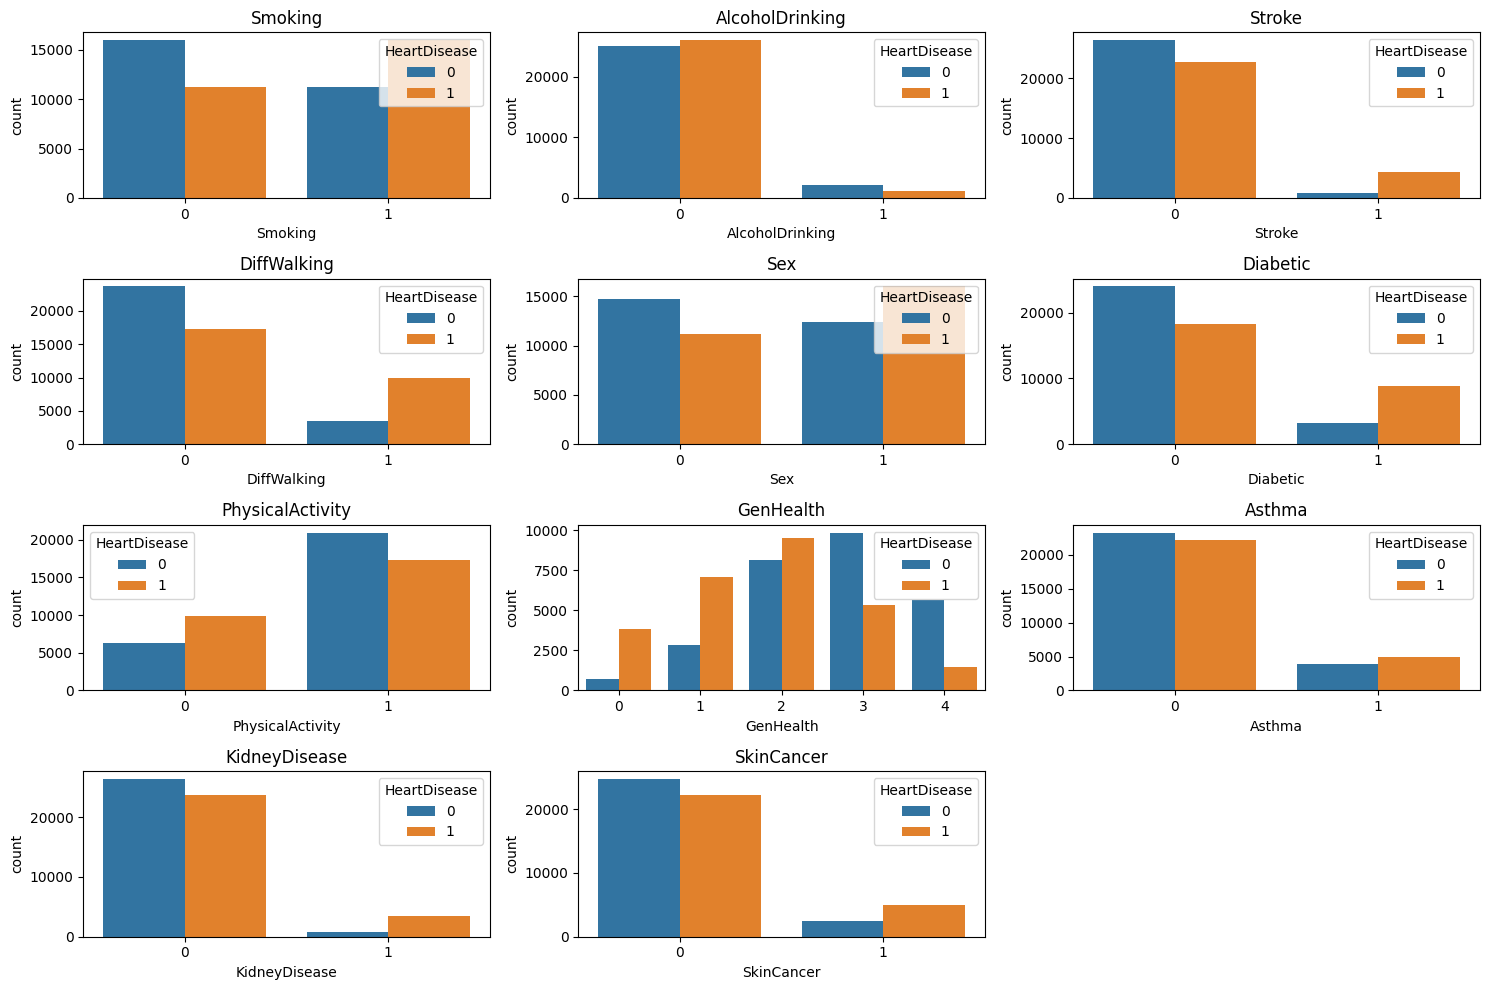

In [40]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(x=col, hue='HeartDisease', data=data, ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis='x')

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

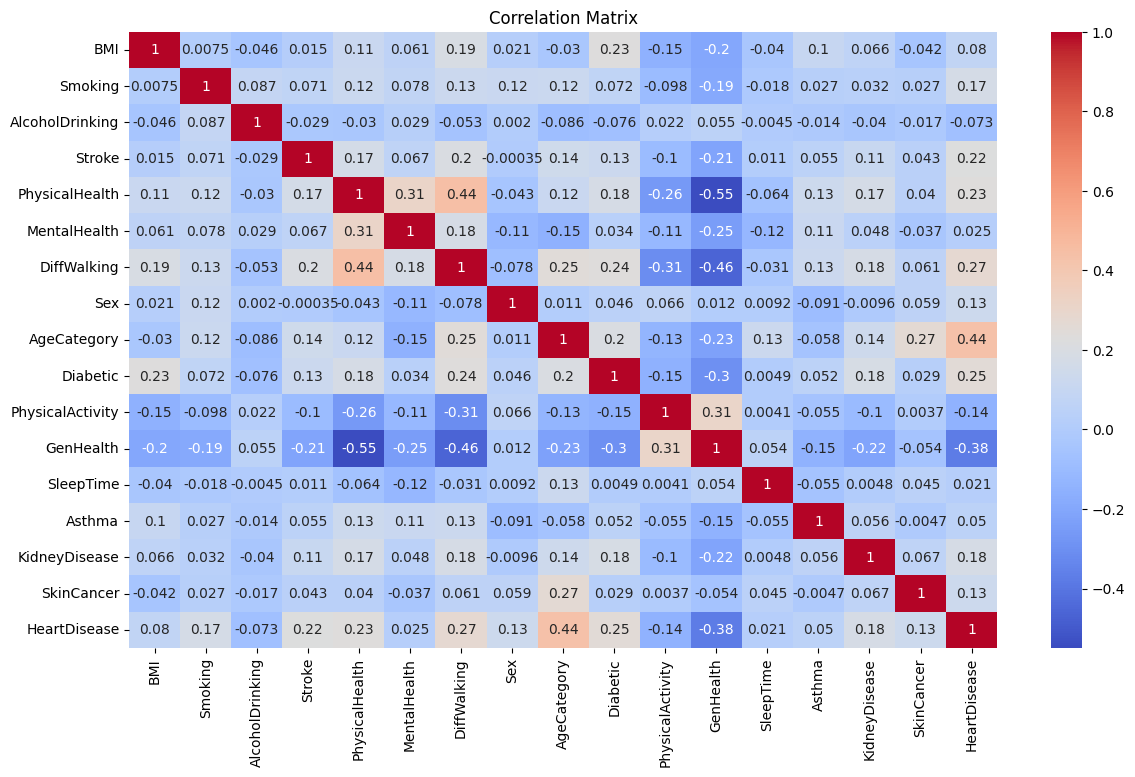

In [41]:
plt.figure(figsize=(14,8))
sns.heatmap(data = data.corr(), annot=True,cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [42]:
X_train, X_test, y_train, y_test = train_test_split(X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced)

In [43]:
from sklearn.ensemble import RandomForestClassifier
model_rf = RandomForestClassifier(random_state=42, n_estimators=300, max_depth=10)
model_rf.fit(X_train, y_train)
y_pred = model_rf.predict(X_test)

In [44]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.78      0.70      0.73      5437
           1       0.72      0.80      0.76      5437

    accuracy                           0.75     10874
   macro avg       0.75      0.75      0.75     10874
weighted avg       0.75      0.75      0.75     10874



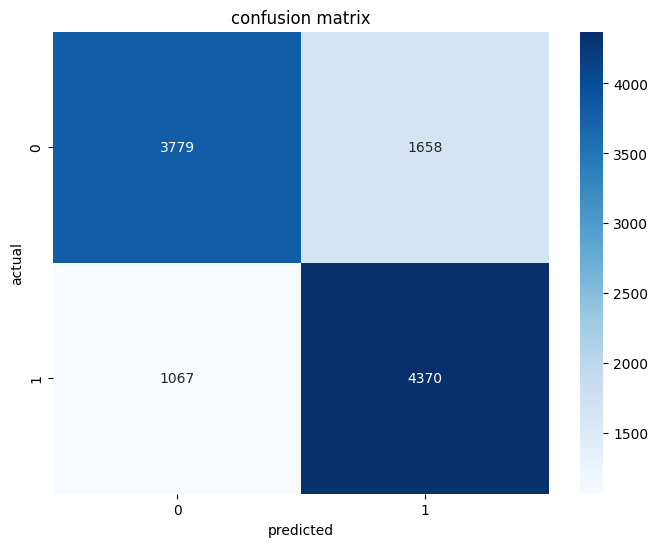

In [45]:
cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize = (8,6))
sns.heatmap(data = cm, cmap='Blues', annot=True, fmt='d', xticklabels=['0','1'],
yticklabels = ['0','1'])
plt.xlabel("predicted")
plt.ylabel("actual")
plt.title("confusion matrix")
plt.show()

In [46]:
importance = model_rf.feature_importances_

feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feat_imp.sort_values(by='Importance', ascending=False, inplace=True)
print(feat_imp[:12])

           Feature  Importance
8      AgeCategory    0.375331
11       GenHealth    0.187283
9         Diabetic    0.071778
6      DiffWalking    0.070018
3           Stroke    0.059788
7              Sex    0.046233
4   PhysicalHealth    0.045095
0              BMI    0.038595
1          Smoking    0.021934
12       SleepTime    0.019444
14   KidneyDisease    0.018896
5     MentalHealth    0.018807


In [47]:
from sklearn.metrics import roc_auc_score, roc_curve

y_proba = model_rf.predict_proba(X_test)[:, 1]
print(roc_auc_score(y_test, y_proba))

0.823873753935468


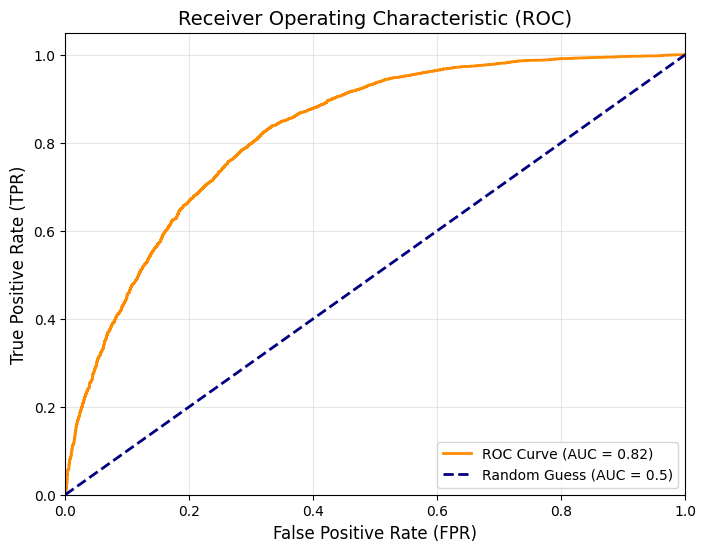

In [48]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color = 'darkorange', lw=2, label = f'ROC Curve (AUC = {roc_auc_score(y_test, y_proba):.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--', lw=2, label='Random Guess (AUC = 0.5)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC)', fontsize=14)
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [49]:
from xgboost import XGBClassifier
model_xgb = XGBClassifier(random_state=42, n_estimators=100, max_depth=5, objective='binary:logistic')
model_xgb.fit(X_train, y_train)
y_pred = model_xgb.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.77      0.70      0.74      5437
           1       0.73      0.79      0.76      5437

    accuracy                           0.75     10874
   macro avg       0.75      0.75      0.75     10874
weighted avg       0.75      0.75      0.75     10874



In [50]:
from sklearn.linear_model import LogisticRegression
model_lr = LogisticRegression(random_state=42, max_iter=1000)
model_lr.fit(X_train, y_train)
y_pred = model_lr.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.76      0.73      0.74      5437
           1       0.74      0.77      0.75      5437

    accuracy                           0.75     10874
   macro avg       0.75      0.75      0.75     10874
weighted avg       0.75      0.75      0.75     10874



In [51]:
from sklearn.tree import DecisionTreeClassifier
model_tr = DecisionTreeClassifier()
model_tr.fit(X_train, y_train)
y_pred = model_tr.predict(X_test)

In [52]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.65      0.65      0.65      5437
           1       0.65      0.66      0.65      5437

    accuracy                           0.65     10874
   macro avg       0.65      0.65      0.65     10874
weighted avg       0.65      0.65      0.65     10874



In [53]:
from sklearn.naive_bayes import GaussianNB
model_NB = GaussianNB()
model_NB.fit(X_train, y_train)
y_pred = model_NB.predict(X_test)

In [54]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.66      0.80      0.72      5437
           1       0.74      0.58      0.65      5437

    accuracy                           0.69     10874
   macro avg       0.70      0.69      0.69     10874
weighted avg       0.70      0.69      0.69     10874



In [55]:
from sklearn.ensemble import GradientBoostingClassifier
model_gb = GradientBoostingClassifier(n_estimators = 200, 
max_depth = 3,
random_state = 42,
learning_rate = 0.1)

model_gb.fit(X_train, y_train)
y_pred = model_gb.predict(X_test)

In [56]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.78      0.70      0.74      5437
           1       0.73      0.80      0.76      5437

    accuracy                           0.75     10874
   macro avg       0.75      0.75      0.75     10874
weighted avg       0.75      0.75      0.75     10874



***Feature Engineering***

In [57]:
risk_columns = ['Smoking', 'Stroke', 'DiffWalking', 'Diabetic', 'Asthma', 'KidneyDisease', 'SkinCancer']
df['Risk_Score'] = df[risk_columns].sum(axis=1)

In [58]:
df['PoorHealthDays'] = df['PhysicalHealth'] + df['MentalHealth']

In [59]:
df['AbnormalSleep'] = df['SleepTime'].apply(lambda x: 1 if x < 7 or x > 9 else 0)

In [60]:
def categorize_bmi(bmi):
    if bmi < 18.5:
        return 0  # Underweight
    elif 18.5 <= bmi < 25:
        return 1  # Normal
    elif 25 <= bmi < 30:
        return 2  # Overweight
    else:
        return 3  # Obese


df['BMI_Category'] = df['BMI'].apply(categorize_bmi)

In [61]:
df[['Risk_Score', 'PoorHealthDays', 'AbnormalSleep', 'BMI_Category']].head()

,Risk_Score,PoorHealthDays,AbnormalSleep,BMI_Category
0,4,33.0,1,0
1,1,0.0,0,1
2,3,50.0,0,2
3,1,0.0,1,1
4,1,28.0,0,1


In [62]:
df_feature = df[['Risk_Score', 'PoorHealthDays', 'AbnormalSleep', 'BMI_Category','Sex', 'AgeCategory','AlcoholDrinking','PhysicalActivity', 'GenHealth','HeartDisease']]

In [63]:
df.columns

Index(['HeartDisease', 'BMI', 'Smoking', 'AlcoholDrinking', 'Stroke',
       'PhysicalHealth', 'MentalHealth', 'DiffWalking', 'Sex', 'AgeCategory',
       'Diabetic', 'PhysicalActivity', 'GenHealth', 'SleepTime', 'Asthma',
       'KidneyDisease', 'SkinCancer', 'Risk_Score', 'PoorHealthDays',
       'AbnormalSleep', 'BMI_Category'],
      dtype='object')

In [64]:
df_feature.info()

<class 'pandas.core.frame.DataFrame'>
Index: 294106 entries, 0 to 319794
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Risk_Score        294106 non-null  int64  
 1   PoorHealthDays    294106 non-null  float64
 2   AbnormalSleep     294106 non-null  int64  
 3   BMI_Category      294106 non-null  int64  
 4   Sex               294106 non-null  int64  
 5   AgeCategory       294106 non-null  int64  
 6   AlcoholDrinking   294106 non-null  int64  
 7   PhysicalActivity  294106 non-null  int64  
 8   GenHealth         294106 non-null  int64  
 9   HeartDisease      294106 non-null  int64  
dtypes: float64(1), int64(9)
memory usage: 24.7 MB


In [65]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scalling_col = ['PoorHealthDays']
df_feature[scalling_col] = scaler.fit_transform(df_feature[scalling_col])
df_feature.head()

,Risk_Score,PoorHealthDays,AbnormalSleep,BMI_Category,Sex,AgeCategory,AlcoholDrinking,PhysicalActivity,GenHealth,HeartDisease
0,4,1.920027,1,0,0,7,0,1,3,0
1,1,-0.599941,0,1,0,12,0,1,3,0
2,3,3.218192,0,2,1,9,0,1,1,0
3,1,-0.599941,1,1,0,11,0,0,2,0
4,1,1.538213,0,1,0,4,0,1,3,0


In [66]:
X_f = df_feature.drop(columns=['HeartDisease'], axis=1)
y_f = df_feature['HeartDisease']

In [67]:
X_f, y_f = rus.fit_resample(X_f, y_f)
y_f.value_counts()

HeartDisease
0    27184
1    27184
Name: count, dtype: int64

In [68]:
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(X_f,y_f,random_state=42,stratify=y_f, test_size=0.2)

In [69]:
model_rf_f = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
model_rf_f.fit(X_train_f, y_train_f)
y_pred = model_rf_f.predict(X_test_f)

In [70]:
print(classification_report(y_test_f, y_pred))

              precision    recall  f1-score   support

           0       0.77      0.69      0.73      5437
           1       0.72      0.80      0.76      5437

    accuracy                           0.75     10874
   macro avg       0.75      0.75      0.74     10874
weighted avg       0.75      0.75      0.74     10874



### **Accuracy is lower than before**

In [71]:
y_proba = model_rf_f.predict_proba(X_test_f)[:, 1]
print(roc_auc_score(y_test_f, y_proba))

0.8193602178602468


## **then, the best Model is "model_rf"**

In [72]:
from sklearn.model_selection import RandomizedSearchCV
param = {
    'n_estimators': [100,200,300],
    'max_depth': [5,10,20]
}

rand = RandomizedSearchCV(model_rf, param, n_iter = 20, cv = 5, scoring = 'f1')
rand.fit(X_train, y_train)

print(rand.best_params_)

{'n_estimators': 300, 'max_depth': 10}


In [73]:
models = {
    'Random Forest': model_rf,
    'XGBoost': model_xgb,
    'Logistic Regression': model_lr,
    'Decision Tree': model_tr,
    'Naive Bayes': model_NB,
    'Gradient Boosting': model_gb
}

Result = []
for name, model in models.items():
    y_pred = model.predict(X_test)
    report = classification_report(y_test, y_pred, output_dict=True)
    Result.append({
        'Model': name,
        'Precision': report['1']['precision'],
        'Recall': report['1']['recall'],
        'F1-Score': report['1']['f1-score'],
        'accuracy': report['accuracy'],
        'AUC': roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    })

print(pd.DataFrame(Result))


                 Model  Precision    Recall  F1-Score  accuracy       AUC
0        Random Forest   0.724950  0.803752  0.762320  0.749402  0.823874
1              XGBoost   0.726385  0.793452  0.758439  0.747287  0.821161
2  Logistic Regression   0.738548  0.771013  0.754432  0.749034  0.822928
3        Decision Tree   0.653289  0.655692  0.654489  0.653853  0.654224
4          Naive Bayes   0.744192  0.583226  0.653949  0.691374  0.787632
5    Gradient Boosting   0.729426  0.798786  0.762532  0.751241  0.826259


(0.0, 1.0)

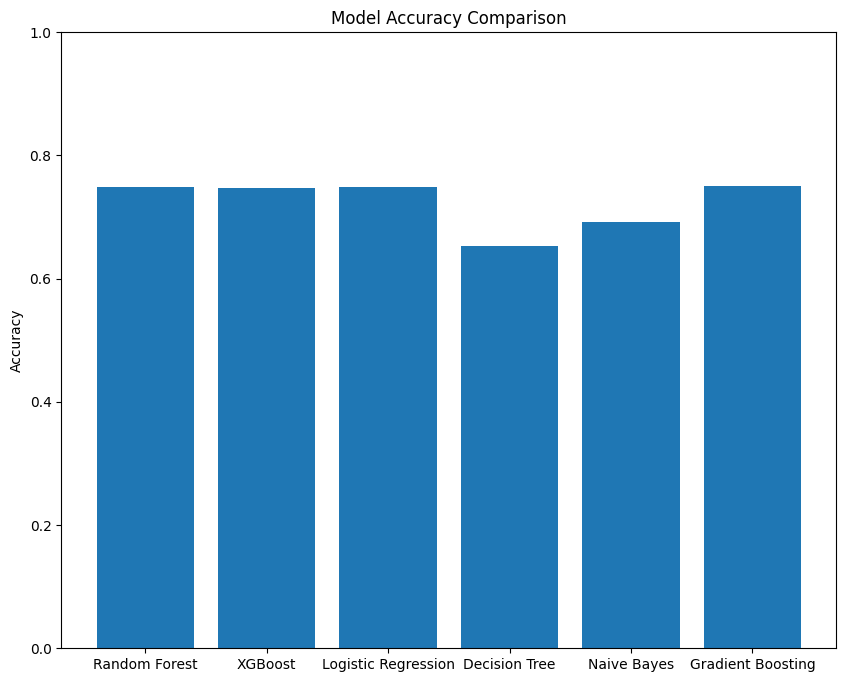

In [74]:
plt.figure(figsize=(10,8))
plt.bar(pd.DataFrame(Result)["Model"], pd.DataFrame(Result)["accuracy"])
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

In [75]:
import joblib

export_data = {
    'model': model_rf,
    'features': list(X.columns)
}

joblib.dump(export_data, 'heart_disease_rf_model.joblib', compress=3)

print("Done!!!!!!!!!")

Done!!!!!!!!!
